<a href="https://colab.research.google.com/github/maxwellugwu/Classification-with-feedforward-networksx-xy26/blob/main/Classification_of_MNIST_data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [16]:
from sklearn.datasets import fetch_openml

# Load the MNIST dataset
mnist = fetch_openml('mnist_784', version=1, as_frame=False)

# Extract features and labels
X, y = mnist.data, mnist.target

print("Shape of X:", X.shape)
print("Shape of y:", y.shape)

Shape of X: (70000, 784)
Shape of y: (70000,)


In [18]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np

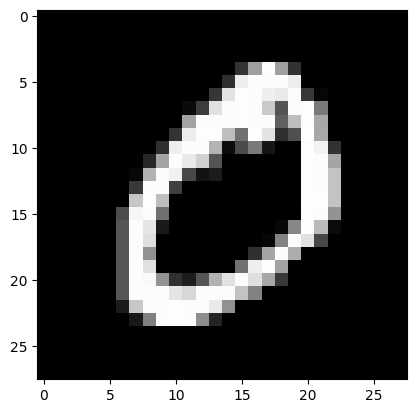

In [19]:
plt.imshow(X[1].reshape(28, 28), cmap='gray')

In [20]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)
X_train.shape

(56000, 784)

In [21]:
xtrain = torch.tensor(X_train, dtype=torch.float32)
ytrain = torch.tensor(y_train.astype(int), dtype=torch.long)
xtest = torch.tensor(X_test, dtype=torch.float32)
ytest = torch.tensor(y_test.astype(int), dtype=torch.long)
ytest

tensor([7, 5, 6,  ..., 9, 9, 0])

In [34]:
class ImageClassify(nn.Module):
  def __init__(self):
    super().__init__()
    self.first =  nn.Linear(784, 28)

    self.second = nn.Linear(28, 16)

    self.third = nn.Linear(16,10)
  def forward(self, x):
    x = F.relu(self.first(x))
    x = F.relu(self.second(x))
    x = self.third(x)
    return x

In [35]:
model = ImageClassify()
loss = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)


print(sum(p.numel() for p in model.parameters()))

# for name, param in model.named_parameters():
#     print(param)

22614


In [36]:
numepoch = 1000
lossvalues = torch.zeros(numepoch)

training_acc = []

for epochi in range(numepoch):
    yhat = model.forward(xtrain)
    losses = loss(yhat, ytrain)
    lossvalues[epochi] = losses



    optimizer.zero_grad()
    losses.backward()
    optimizer.step()


    # compute accuracy
    matches = torch.argmax(yhat,axis=1) == ytrain # booleans (false/true)
    matchesNumeric = matches.float()              # convert to numbers (0/1)
    accuracyPct = 100*torch.mean(matchesNumeric)  # average and x100
    training_acc.append( accuracyPct )            # add to list of accuracies

    # final forward pass
predictions = model.forward(xtrain)

predlabels = torch.argmax(predictions,axis=1)
totalacc = 100*torch.mean((predlabels == ytrain).float())


In [37]:
for name, param in model.named_parameters():
    print(name, param.data)
print(totalacc)

first.weight tensor([[-0.0284,  0.0251, -0.0277,  ..., -0.0214, -0.0189, -0.0124],
        [-0.0045,  0.0357, -0.0274,  ..., -0.0042,  0.0306, -0.0065],
        [-0.0032,  0.0284,  0.0120,  ...,  0.0222, -0.0218,  0.0179],
        ...,
        [ 0.0093, -0.0184,  0.0018,  ...,  0.0213, -0.0105, -0.0274],
        [ 0.0208, -0.0193,  0.0034,  ...,  0.0288, -0.0246, -0.0326],
        [ 0.0179,  0.0140,  0.0348,  ...,  0.0283,  0.0075,  0.0053]])
first.bias tensor([-0.0383,  0.0016, -0.0182, -0.0282,  0.0068,  0.0466, -0.0764,  0.0334,
         0.0243,  0.1015, -0.0394, -0.0236, -0.0420, -0.0724, -0.0421,  0.0293,
        -0.0069, -0.0469,  0.0139,  0.0020, -0.0325, -0.0446,  0.6273,  0.0270,
         0.0249, -0.0015,  0.0012,  0.0654])
second.weight tensor([[ 1.4677e-01, -5.7441e-02,  1.6545e-01, -1.2677e-01, -9.1544e-02,
          1.7971e-02,  1.1677e-01, -1.1040e-03,  1.7290e-01,  3.9895e-02,
          7.3126e-02, -1.2418e-01, -7.3227e-02,  1.7510e-02, -1.6441e-01,
          1.2074e-01,

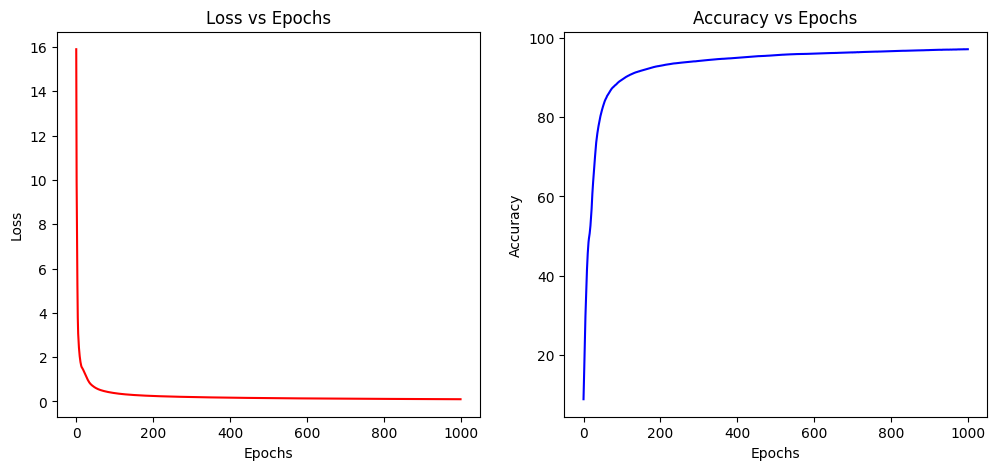

In [38]:
fig , ax = plt.subplots(1,2, figsize=(12,5))
ax[0].plot(lossvalues.detach(),'r')
ax[0].set_xlabel('Epochs')
ax[0].set_ylabel('Loss')
ax[0].set_title('Loss vs Epochs')

ax[1].plot(training_acc, 'b')
ax[1].set_xlabel('Epochs')
ax[1].set_ylabel('Accuracy')
ax[1].set_title('Accuracy vs Epochs')
plt.show()

In [39]:
predictions_for_test_data = model.forward(xtest)

predlabels1 = torch.argmax(predictions_for_test_data,axis=1)
testacc = 100*torch.mean((predlabels1 == ytest).float())
print(testacc)

tensor(93.8000)


In [40]:
predictions_for_test_data.shape

torch.Size([14000, 10])

In [41]:
result = model.forward(xtest[18])
predlabels2 = torch.argmax(result)
predlabels2

tensor(5)

In [42]:
result.shape

torch.Size([10])

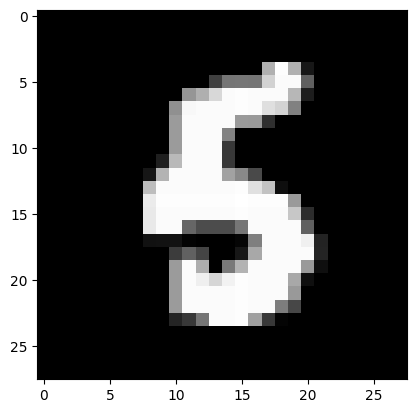

In [43]:
plt.imshow(xtest[18].reshape(28, 28), cmap='gray')

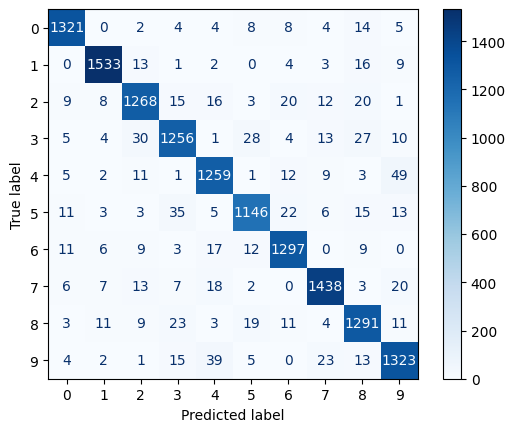

In [44]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

cm = confusion_matrix(ytest, predlabels1)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')
plt.show()